# Goal-Conditioned RL for Complex Tasks

## 📚 Learning Objectives

By completing this notebook, you will:
- Understand goal-conditioned RL
- Implement goal-conditioned policies
- Apply to complex multi-task problems
- Understand universal value functions

## 🔗 Prerequisites

- ✅ Understanding of RL fundamentals
- ✅ Understanding of value functions
- ✅ Python knowledge

---

## Official Structure Reference

This notebook covers practical activities from **Course 09, Unit 5**:
- Implementing goal-conditioned RL for complex tasks

---

## Introduction

**Goal-conditioned RL** learns policies that can achieve different goals, enabling generalization across tasks and efficient multi-task learning.

## Lesson Brief

This lesson introduces goal-conditioned RL, where the same environment can present different targets and the policy must adapt to each one.

Students will see why the goal itself becomes part of the decision problem.

Why this matters: many practical systems must solve many related tasks, not only one fixed task forever.

This lesson shows how RL can generalize across goals.

### If Python feels hard right now

- Run code cells **from top to bottom** the first time; later you can re-run one cell after you change it.
- In code cells, a line that starts with `# ` (hash + space) is a **hint for the very next line**—read the hint, then read the code under it.
- You do **not** need to memorize syntax. Follow the story: *what is stored*, *what gets printed*, and *what the plot is trying to show*.
- If something errors, read the last line of the red traceback first—it usually names the problem in plain language.


## Recommended YouTube Video

To reinforce this lesson, watch **Olivier Sigaud - "Goal-conditioned reinforcement learning: hindsight experience replay"**:
[Watch on YouTube](https://www.youtube.com/watch?v=0EDiC__RcCA)

Why this pick:
- Clear academic English and very focused topic coverage.
- Explains goal-conditioned RL through hindsight experience replay in a compact way.
- Good for students who need the key idea without a long detour into unrelated deep RL topics.

## Student Support Pack

Use this section as a checkpoint before and after the main code cells so the idea stays clearer than the syntax.

### Key Terms
- Goal-conditioned policy: acts based on a target goal.
- Goal signal: the requested outcome.
- Generalization across goals: one learner for many related targets.
- Success criterion: how we judge goal completion.
- Universal value function idea: value estimates depend on both state and goal.

### Quick Check
- Why include the goal in the input?
- How is this different from one fixed task?
- What flexibility does this add?
- Why is goal-conditioned RL not automatically the same as meta-learning?

### Common Mistakes
- Thinking every new goal needs a new agent.
- Forgetting the goal is part of the input.
- Confusing current state with target state.
- Treating goal-conditioned RL, multi-task learning, and few-shot learning as identical ideas.


## Goal-Conditioned RL Is Not the Same as Meta-Learning

This distinction is important because students often mix several advanced ideas together.

### Goal-conditioned RL

Goal-conditioned RL says:

`Use the current state and the requested goal together when choosing actions.`

The same learner can then solve many related targets inside one environment.

### Meta-learning

Meta-learning asks a different question:

`How can a learner adapt quickly to a new task from limited experience?`

That is a broader adaptation problem.

### The connection

Goal-conditioned RL can support multi-goal behavior and some kinds of generalization.
But it is **not automatically** a full few-shot or meta-learning method.

### Teaching takeaway

Students should leave this notebook saying:

- goal-conditioned RL -> one policy, many goals
- meta-learning -> fast adaptation across tasks

They are related, but not identical.

## Inputs and Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---


### Step Guide

**What this cell does:** Import libraries and set small global constants for the lesson.

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Printed numbers, small tables, logs, or figures tied to the current section header.

**If you feel lost:** Skim only the `#` lines in the next cell, run it once, then re-read the same hints with the output visible.


In [1]:
# Setup step: import the libraries that will carry the math, plotting, and learning logic.
# Reading the imports first helps students see which tools each later cell depends on.

# Load a library so you can use its ready-made functions and types below.
import numpy as np

# Show text or numbers in the cell output area under the code.
print("✅ Libraries imported!")
# Show text or numbers in the cell output area under the code.
print("\nGoal-Conditioned RL for Complex Tasks")
# Show text or numbers in the cell output area under the code.
print("=" * 60)

# Show text or numbers in the cell output area under the code.
print("\nGoal-Conditioned RL:")
# Show text or numbers in the cell output area under the code.
print("  - Policy: π(a|s,g) - action given state AND goal")
# Show text or numbers in the cell output area under the code.
print("  - Value: Q(s,a,g) or V(s,g) - value given goal")
# Show text or numbers in the cell output area under the code.
print("  - Universal: Works for any goal")

# Show text or numbers in the cell output area under the code.
print("\nBenefits:")
# Show text or numbers in the cell output area under the code.
print("  - Multi-task learning")
# Show text or numbers in the cell output area under the code.
print("  - Generalization")
# Show text or numbers in the cell output area under the code.
print("  - Few-shot learning")
# Show text or numbers in the cell output area under the code.
print("  - Hierarchical abstraction")

# Show text or numbers in the cell output area under the code.
print("\nApplications:")
# Show text or numbers in the cell output area under the code.
print("  - Robotics (reach different positions)")
# Show text or numbers in the cell output area under the code.
print("  - Navigation (reach different locations)")
# Show text or numbers in the cell output area under the code.
print("  - Manipulation (achieve different states)")

# Show text or numbers in the cell output area under the code.
print("\n✅ Goal-conditioned RL concepts understood!")


✅ Libraries imported!

Goal-Conditioned RL for Complex Tasks

Goal-Conditioned RL:
  - Policy: π(a|s,g) - action given state AND goal
  - Value: Q(s,a,g) or V(s,g) - value given goal
  - Universal: Works for any goal

Benefits:
  - Multi-task learning
  - Generalization
  - Few-shot learning
  - Hierarchical abstraction

Applications:
  - Robotics (reach different positions)
  - Navigation (reach different locations)
  - Manipulation (achieve different states)

✅ Goal-conditioned RL concepts understood!


## Worked Example: One Policy, Many Goals

A goal-conditioned agent does not learn only `what action is good in this state?`

It learns:

`what action is good in this state for this specific goal?`

That matters when the same environment can ask for different targets, such as:
- reach different shelves in a warehouse
- move a robot arm to different coordinates
- navigate to different rooms in a building

### Step Guide

**What this cell does:** Import libraries and set small global constants for the lesson.

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Printed numbers, small tables, logs, or figures tied to the current section header.

**If you feel lost:** Skim only the `#` lines in the next cell, run it once, then re-read the same hints with the output visible.


In [2]:
# Setup step: import the libraries that will carry the math, plotting, and learning logic.
# Reading the imports first helps students see which tools each later cell depends on.

# Load a library so you can use its ready-made functions and types below.
import numpy as np

# Save a value in a name so the next lines can read it.
GRID_SIZE = 5
# Another assignment—same idea: store a value for the lines below.
START = (2, 2)
# Another assignment—same idea: store a value for the lines below.
GOALS = [(0, 4), (4, 0), (0, 0)]


# Function `goal_conditioned_action` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: state, goal.
def goal_conditioned_action(state, goal):
    # Save a value in a name so the next lines can read it.
    row, col = state
    # Another assignment—same idea: store a value for the lines below.
    goal_row, goal_col = goal
    # If the condition is True, run the indented block under this line.
    if row < goal_row:
        # Send a value back to whoever called this function.
        return "down"
    # If the condition is True, run the indented block under this line.
    if row > goal_row:
        # Send a value back to whoever called this function.
        return "up"
    # If the condition is True, run the indented block under this line.
    if col < goal_col:
        # Send a value back to whoever called this function.
        return "right"
    # If the condition is True, run the indented block under this line.
    if col > goal_col:
        # Send a value back to whoever called this function.
        return "left"
    # Send a value back to whoever called this function.
    return "stay"


# Function `apply_action` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: state, action.
def apply_action(state, action):
    # Save a value in a name so the next lines can read it.
    row, col = state
    # If the condition is True, run the indented block under this line.
    if action == "up":
        # Use a temporary list to format one printed row of the grid.
        row -= 1
    # Else-if: only checked when the earlier if/elif tests were False.
    elif action == "down":
        # Use a temporary list to format one printed row of the grid.
        row += 1
    # Else-if: only checked when the earlier if/elif tests were False.
    elif action == "left":
        # Save a value in a name so the next lines can read it.
        col -= 1
    # Else-if: only checked when the earlier if/elif tests were False.
    elif action == "right":
        # Save a value in a name so the next lines can read it.
        col += 1
    # Use a temporary list to format one printed row of the grid.
    row = min(max(row, 0), GRID_SIZE - 1)
    # Save a value in a name so the next lines can read it.
    col = min(max(col, 0), GRID_SIZE - 1)
    # Send a value back to whoever called this function.
    return (row, col)


# Function `rollout_to_goal` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: start, goal.
def rollout_to_goal(start, goal):
    # Create or choose a variable used in the Bellman warm-up demo.
    state = start
    # Save a value in a name so the next lines can read it.
    trajectory = [state]
    # Another assignment—same idea: store a value for the lines below.
    actions = []
    # Start a loop: repeat the indented block while the condition stays True.
    while state != goal:
        # Save a value in a name so the next lines can read it.
        action = goal_conditioned_action(state, goal)
        # Add one new item to the end of a list (the list grows in place).
        actions.append(action)
        # Create or choose a variable used in the Bellman warm-up demo.
        state = apply_action(state, action)
        # Add one new item to the end of a list (the list grows in place).
        trajectory.append(state)
        # If the condition is True, run the indented block under this line.
        if len(trajectory) > 20:
            # Stop the loop completely and continue after the loop block.
            break
    # Send a value back to whoever called this function.
    return actions, trajectory


# Start a loop: repeat the indented block once per item in the sequence.
for goal in GOALS:
    # Save a value in a name so the next lines can read it.
    actions, trajectory = rollout_to_goal(START, goal)
    # Show text or numbers in the cell output area under the code.
    print(f"Goal: {goal}")
    # Show text or numbers in the cell output area under the code.
    print(" Actions:", actions)
    # Show text or numbers in the cell output area under the code.
    print(" Trajectory:", trajectory)
    # Show text or numbers in the cell output area under the code.
    print()

# Show text or numbers in the cell output area under the code.
print("Teaching point:")
# Show text or numbers in the cell output area under the code.
print("The decision rule changes when the goal changes, even if the current state stays the same.")
# Show text or numbers in the cell output area under the code.
print("That is the central idea of goal-conditioned RL.")


Goal: (0, 4)
 Actions: ['up', 'up', 'right', 'right']
 Trajectory: [(2, 2), (1, 2), (0, 2), (0, 3), (0, 4)]

Goal: (4, 0)
 Actions: ['down', 'down', 'left', 'left']
 Trajectory: [(2, 2), (3, 2), (4, 2), (4, 1), (4, 0)]

Goal: (0, 0)
 Actions: ['up', 'up', 'left', 'left']
 Trajectory: [(2, 2), (1, 2), (0, 2), (0, 1), (0, 0)]

Teaching point:
The decision rule changes when the goal changes, even if the current state stays the same.
That is the central idea of goal-conditioned RL.


In [3]:
# References (shown with Markdown inside a Python cell — avoids SyntaxError if a Markdown block is run as code.)
from IPython.display import Markdown, display

display(Markdown(r"""## 📚 References & Further Reading

### Books
- Sutton & Barto — [Reinforcement Learning: An Introduction](http://incompleteideas.net/book/the-book-2nd.html) (free online, the RL bible)

### Papers
- Mnih et al. (2015) — [Human-level control through deep RL (DQN)](https://www.nature.com/articles/nature14236)
- Silver et al. (2016) — [AlphaGo](https://www.nature.com/articles/nature16961)

### State-of-the-art OpenAI Five beat world champions in Dota2; AlphaFold uses RL-like optimization for protein folding.
"""))


## 📚 References & Further Reading

### Books
- Sutton & Barto — [Reinforcement Learning: An Introduction](http://incompleteideas.net/book/the-book-2nd.html) (free online, the RL bible)

### Papers
- Mnih et al. (2015) — [Human-level control through deep RL (DQN)](https://www.nature.com/articles/nature14236)
- Silver et al. (2016) — [AlphaGo](https://www.nature.com/articles/nature16961)

### State-of-the-art OpenAI Five beat world champions in Dota2; AlphaFold uses RL-like optimization for protein folding.


## Summary

This notebook showed why goal-conditioned RL is useful:

- the environment can stay the same
- the desired goal can change from episode to episode
- the policy must therefore depend on both **state** and **goal**

### Main takeaway

Goal-conditioned policies are a natural fit for multi-target tasks such as
navigation, robotics, and manipulation, where one agent must solve many related
objectives instead of only one fixed task.

### Step Guide

**What this cell does:** Try to auto-plot lesson numbers already in memory (optional recap charts).

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Either one or more plots, or a short message that nothing was auto-plotted.

**If you feel lost:** Re-run the main lesson cells so numeric variables exist, then try this recap again.


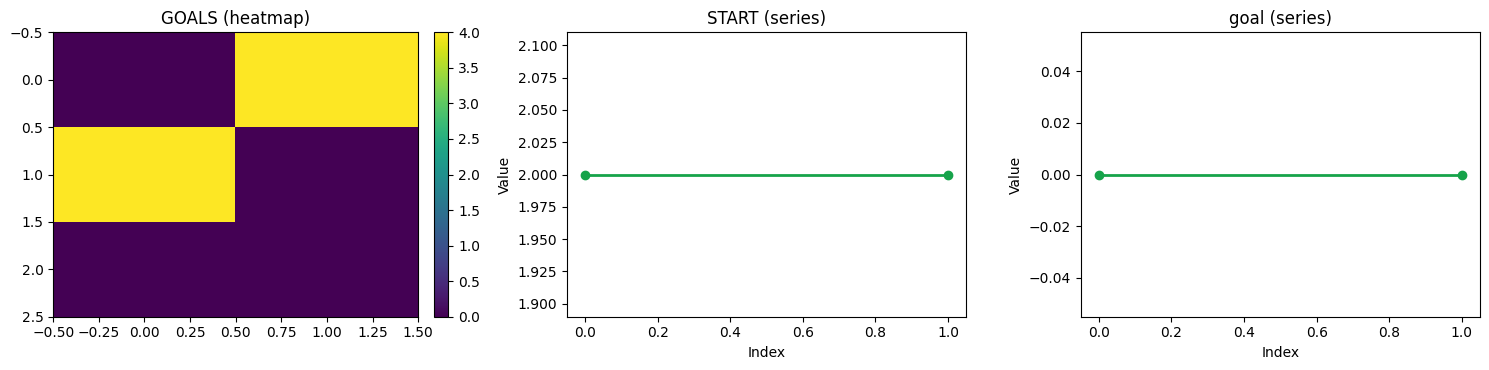

In [4]:
# Visual recap: turn the lesson's numeric artifacts into quick charts.
# The goal is to help students see patterns that are harder to catch from raw printed output alone.
# Load a library so you can use its ready-made functions and types below.
import numbers
# Load a library so you can use its ready-made functions and types below.
import numpy as np
# Load a library so you can use its ready-made functions and types below.
import matplotlib.pyplot as plt

# Function `_is_number` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: value.
def _is_number(value):
    # Send a value back to whoever called this function.
    return isinstance(value, (int, float, np.integer, np.floating)) and not isinstance(value, bool)

# Function `_as_numeric_dict` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: value.
def _as_numeric_dict(value):
    # If the condition is True, run the indented block under this line.
    if not isinstance(value, dict) or not value or len(value) > 12:
        # Send a value back to whoever called this function.
        return None
    # Collect numeric dict values after validation for plotting.
    converted = []
    # Start a loop: repeat the indented block once per item in the sequence.
    for item in value.values():
        # If the condition is True, run the indented block under this line.
        if not _is_number(item):
            # Send a value back to whoever called this function.
            return None
        # Add one new item to the end of a list (the list grows in place).
        converted.append(float(item))
    # Send a value back to whoever called this function.
    return [str(key) for key in value.keys()], np.asarray(converted, dtype=float)

# Function `_as_numeric_array` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: value, dims.
def _as_numeric_array(value, dims):
    # Try/except/finally: structured error handling around risky operations.
    try:
        # Temporary ndarray after coercion attempt inside _as_numeric_array().
        array = np.asarray(value, dtype=float)
    # Try/except/finally: structured error handling around risky operations.
    except Exception:
        # Send a value back to whoever called this function.
        return None
    # If the condition is True, run the indented block under this line.
    if array.ndim != dims:
        # Send a value back to whoever called this function.
        return None
    # If the condition is True, run the indented block under this line.
    if dims == 1 and not (2 <= array.size <= 200):
        # Send a value back to whoever called this function.
        return None
    # If the condition is True, run the indented block under this line.
    if dims == 2 and array.size > 400:
        # Send a value back to whoever called this function.
        return None
    # Send a value back to whoever called this function.
    return array

# Preferred global names to try first when auto-picking lesson plots.
priority_names = [
    # Execute: "reward_history", "episode_rewards", "returns", "value_history", "q_values", "Q", "V",
    "reward_history", "episode_rewards", "returns", "value_history", "q_values", "Q", "V",
    # Execute: "scores", "metrics", "counts", "reward_grid", "values", "allocations", "application_scores …
    "scores", "metrics", "counts", "reward_grid", "values", "allocations", "application_scores"
# Execute: ]
]

# Names that are never lesson metrics (imports / plotting handles).
skip_names = {"np", "plt", "numbers", "math", "Figure", "fig"}
# Save a value in a name so the next lines can read it.
candidates = []
# Track which names were already visited to avoid duplicates.
seen = set()
# Ordered list of global names to scan for plottable numeric artifacts.
search_space = priority_names + sorted(name for name in globals() if not name.startswith("_"))

# Start a loop: repeat the indented block once per item in the sequence.
for name in search_space:
    # If the condition is True, run the indented block under this line.
    if name in seen or name not in globals() or name in skip_names:
        # Skip to the next lap of the loop (ignore the rest of this lap).
        continue
    # Execute: seen.add(name)
    seen.add(name)
    # The runtime object bound to that global name.
    value = globals()[name]

    # Try to interpret a global variable as a plottable payload (or None if not).
    dict_payload = _as_numeric_dict(value)
    # If the condition is True, run the indented block under this line.
    if dict_payload is not None:
        # Add one new item to the end of a list (the list grows in place).
        candidates.append(("dict", name, dict_payload))
        # If the condition is True, run the indented block under this line.
        if len(candidates) == 3:
            # Stop the loop completely and continue after the loop block.
            break
        # Skip to the next lap of the loop (ignore the rest of this lap).
        continue

    # Try to interpret a global variable as a plottable payload (or None if not).
    array_2d = _as_numeric_array(value, 2)
    # If the condition is True, run the indented block under this line.
    if array_2d is not None:
        # Add one new item to the end of a list (the list grows in place).
        candidates.append(("heatmap", name, array_2d))
        # If the condition is True, run the indented block under this line.
        if len(candidates) == 3:
            # Stop the loop completely and continue after the loop block.
            break
        # Skip to the next lap of the loop (ignore the rest of this lap).
        continue

    # Try to interpret a global variable as a plottable payload (or None if not).
    array_1d = _as_numeric_array(value, 1)
    # If the condition is True, run the indented block under this line.
    if array_1d is not None:
        # Append one value to a list (mutates the list in place).
        # Skip misleading line plots for last-step env vectors (not time series).
        # If the condition is True, run the indented block under this line.
        if name in {"obs", "next_obs", "state", "action"} and array_1d.size <= 16:
            # Skip to the next lap of the loop (ignore the rest of this lap).
            continue
        # Add one new item to the end of a list (the list grows in place).
        candidates.append(("line", name, array_1d))
        # If the condition is True, run the indented block under this line.
        if len(candidates) == 3:
            # Stop the loop completely and continue after the loop block.
            break

# If the condition is True, run the indented block under this line.
if not candidates:
    # Build a small dict used only for the fallback summary bar chart.
    summary = {
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "functions": sum(callable(value) for value in globals().values()),
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "classes": sum(isinstance(value, type) for value in globals().values()),
        # One key/value row inside a dict literal (domain -> fields or nested table).
        "numeric vars": sum(_is_number(value) for value in globals().values()),
    # Part of a dict/set literal layout (syntax grouping).
    }
    # Unpack Matplotlib figure and axes array created by subplots().
    fig, ax = plt.subplots(figsize=(6, 3.5))
    # Work on one plot panel: title, tick marks, axis labels, or drawings on that panel.
    ax.bar(summary.keys(), summary.values(), color=["#2563eb", "#16a34a", "#f59e0b"])
    # Same plot panel as the line above—one more small plotting tweak.
    ax.set_title("Notebook artifact summary")
    # Same plot panel as the line above—one more small plotting tweak.
    ax.set_ylabel("Count")
    # Start a loop: repeat the indented block once per item in the sequence.
    for idx, value in enumerate(summary.values()):
        # Same plot panel as the line above—one more small plotting tweak.
        ax.text(idx, value + 0.05, str(value), ha="center")
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.tight_layout()
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.show()
# Else: run this block when none of the if/elif tests above matched.
else:
    # Unpack Matplotlib figure and axes array created by subplots().
    fig, axes = plt.subplots(1, len(candidates), figsize=(5 * len(candidates), 3.8))
    # If the condition is True, run the indented block under this line.
    if len(candidates) == 1:
        # Save a value in a name so the next lines can read it.
        axes = [axes]

    # Start a loop: repeat the indented block once per item in the sequence.
    for ax, (kind, name, payload) in zip(axes, candidates):
        # If the condition is True, run the indented block under this line.
        if kind == "dict":
            # Unpack plotting payload for dict bar charts (keys vs numeric values).
            labels, values = payload
            # Work on one plot panel: title, tick marks, axis labels, or drawings on that panel.
            ax.bar(range(len(values)), values, color="#2563eb")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_xticks(range(len(values)))
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_xticklabels(labels, rotation=45, ha="right")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_title(f"{name} (dict)")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_ylabel("Value")
        # Else-if: only checked when the earlier if/elif tests were False.
        elif kind == "line":
            # Same plot panel as the line above—one more small plotting tweak.
            ax.plot(payload, marker="o", linewidth=2, color="#16a34a")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_title(f"{name} (series)")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_xlabel("Index")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_ylabel("Value")
        # Else: run this block when none of the if/elif tests above matched.
        else:
            # Image handle returned by imshow for attaching a colorbar.
            image = ax.imshow(payload, aspect="auto", cmap="viridis")
            # Same plot panel as the line above—one more small plotting tweak.
            ax.set_title(f"{name} (heatmap)")
            # Change something about the whole figure (not just one small subplot).
            fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)

    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.tight_layout()
    # Use pyplot to create or tweak a figure (plot, labels, show, etc.).
    plt.show()


## Closing Takeaway

**Teaching takeaway:** Goal-conditioned RL trains one policy to solve many targets by making the goal part of the agent input.

**If students remember one idea:** A policy can become more flexible when it is trained to answer not only what state it is in, but also what outcome it should reach.

**Quick check before moving on:**
- Can you explain what changes in the policy input when goals are included explicitly?
- Can you describe why goal-conditioned learning can support reuse across many tasks?

**Bridge to the next step:** This completes the advanced applications unit and helps students see how RL ideas generalize beyond one fixed task.

**For weaker coders:** After you run the important cells, write one sentence: *what number or plot changed, and does that match what the lesson said should happen?* If not, re-read only the `#` hint lines in that cell—not every line of Python.


## Motion recap (optional)

**Why this cell exists:** many RL ideas are easiest to sanity-check when you can **watch time unfold** — a state changes because an action was taken, then a reward signal arrives.

**FrozenLake here is a shared toy picture** (not the “whole story” of every method in this notebook):
- Treat it as a **concrete instance** of the vocabulary you already used: **state** = which tile, **action** = move direction, **reward** = goal / hole / step, **episode** = from start until stop.

**Map this picture to your lesson (pick what fits):**
- **MDPs / value iteration / DP ideas:** ask what a “good tile” should be worth *on the way* to the goal, and what a hole implies for long-horizon returns.
- **Policy evaluation / Monte Carlo / TD / Q-learning / SARSA:** relate the moves you see to **estimated values or Q(s,a)** and to the **backup** idea you implemented above.
- **Exploration vs exploitation / UCB / tuning ε:** random moves are a deliberate exaggeration — compare **wide wandering** vs a mostly greedy path, and connect that to the exploration rule you studied in this unit.
- **Deep RL / training at scale:** use this as a **minimal loop** (observe → act → reward → learn) while remembering real applications change the **observation**, not the basic cycle.

The policy in the next cell is **random on purpose** so the GIF/slider foreground **transitions**, not a claim that this notebook’s full method is already optimal on this map.

### Why the agent may never reach the gift (goal tile `G`)
The code uses **uniform random actions**. That is **not** trying to “solve” FrozenLake or show a hero run to the goal. The point is to show **typical transitions**: safe tiles, edges, sometimes holes, sometimes lucky progress. **Not reaching `G` is expected** and still useful — read the **sequence** (state → action → next state → reward), not “did it win in 10 seconds?”

### Quick student check (about 60 seconds)
- Scroll to **one core code cell above** that carries the main idea of this lesson (policy update, backup, ε-rule, training step, …).
- In one sentence, name **one symbol or variable** from that cell that lines up with **state**, **action**, or **reward** in the FrozenLake frames.
- If you cannot name a match yet, re-run the main lesson cells once, then return here — the GIF is a **mirror** for vocabulary, not a replacement for the definitions.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


Motion recap | return=0.0 | frames=7 | term=True | trunc=False


objc[77858]: Class SDL_RumbleMotor is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x10ff08138) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x1104049c8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[77858]: Class SDL_RumbleContext is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x10ff08188) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x110404a18). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[77858]: Class SDLApplication is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x10ff07c88) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x110404a68). T

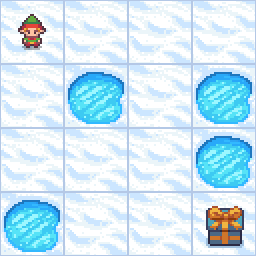

In [5]:
# MOTION_RECAP_COURSE09 — shared optional visual (FrozenLake GIF + step slider).

%pip install pillow ipywidgets -q

import pathlib
import sys

import numpy as np

for _d in [pathlib.Path.cwd().resolve(), *pathlib.Path.cwd().resolve().parents]:
    if (_d / "course09_step_viz.py").exists():
        _course09 = _d
        break
else:
    raise FileNotFoundError(
        "Could not find course09_step_viz.py — open this notebook from inside Course 09 "
        "(normal Jupyter / Cursor layout) so parent folders include the Course 09 root."
    )

if str(_course09) not in sys.path:
    sys.path.insert(0, str(_course09))

import gymnasium as gym
import course09_step_viz as cs9viz


def _random_policy(obs, step):
    return int(np.random.randint(0, 4))


env = gym.make("FrozenLake-v1", map_name="4x4", is_slippery=False, render_mode="rgb_array")
frames, total_r, terminated, truncated = cs9viz.collect_rollout_frames(
    env, _random_policy, max_steps=48, seed=42
)
env.close()
print(
    f"Motion recap | return={total_r:.1f} | frames={len(frames)} | term={terminated} | trunc={truncated}"
)
cs9viz.display_gif(frames, duration_ms=110)
cs9viz.display_step_slider(frames, title="FrozenLake — timestep")


## Did you understand? (about 2 minutes)

<!-- STUDENT_SELF_CHECK_COURSE09 -->

Answer **without scrolling** first. Then scroll only to compare with the notebook.

1. **One sentence:** What is the *single main idea* you are supposed to carry to the next lesson?
2. **Trace one step:** Pick one moment from this notebook (a number you printed, a plot, a table, or a GIF/slider frame). Write **state → action → reward → next state** in your own words — even if your “state” is a vector or a tile index.
3. **One honest confusion:** Write one question you still have. That question is what you should bring to class, study group, or office hours.

**If any answer is blank:** run the notebook again from the top **slowly** (run one cell → read the output → only then run the next).

**Remember:** a clean run means the code worked — it does **not** automatically mean every idea clicked. Confusion is normal until you can do steps 1–2 in plain language.
